In [ ]:
#data collection
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Downloads\Sentiment & Mental Health Dataset (Reddit-Based)\Sentiment_Mental_health_dataset.csv")

print(df.head())

                                           statement                status
0  Anyone else have symptoms much improved after ...               Bipolar
1  I basicaly do not exist, sure feels that way. ...              Suicidal
2  Finding a sense of self It's like one minute I...  Personality_disorder
3  Putting into words what were just tangles in m...               Anxiety
4  Anxiety makes me worry about my public image s...               Anxiety


In [4]:
df.columns = ["text", "label"]

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26350 entries, 0 to 26349
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    26350 non-null  object
 1   label   26350 non-null  object
dtypes: object(2)
memory usage: 411.8+ KB
None


In [6]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [7]:
print(df.duplicated().sum())

17


In [8]:
df = df.drop_duplicates()

In [9]:
print(df.duplicated().sum())

0


In [10]:
print(df['label'].unique())

['Bipolar' 'Suicidal' 'Personality_disorder' 'Anxiety' 'Depression'
 'Stress' 'Normal']


In [11]:
print(df['label'].value_counts())

label
Suicidal                5592
Anxiety                 4704
Normal                  4574
Depression              4111
Personality_disorder    2810
Bipolar                 2720
Stress                  1822
Name: count, dtype: int64


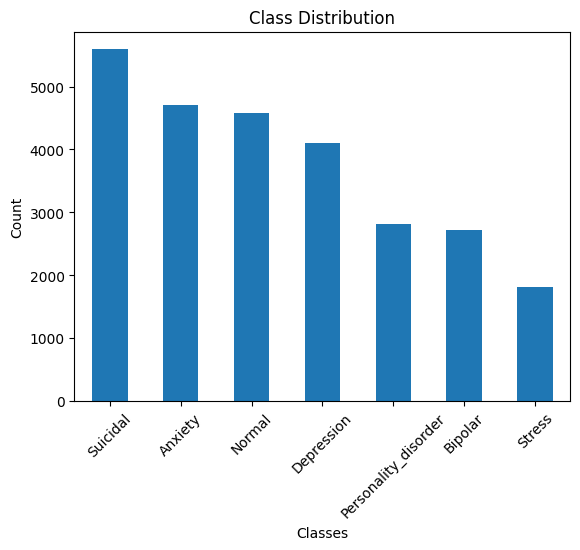

In [12]:
#EDA
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

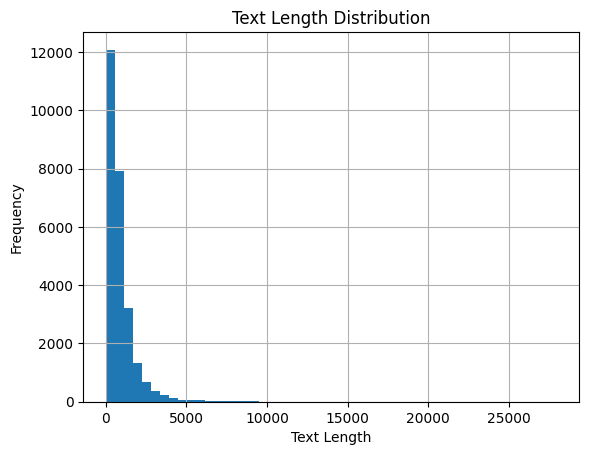

In [13]:
df['text_length'] = df['text'].apply(len)

df['text_length'].hist(bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [14]:
print(df['text_length'].describe())

count    26333.000000
mean       908.390537
std       1144.513479
min          1.000000
25%        338.000000
50%        615.000000
75%       1093.000000
max      27963.000000
Name: text_length, dtype: float64


In [15]:
from collections import Counter
import re

all_text = " ".join(df['text'])

words = re.findall(r'\w+', all_text.lower())

common_words = Counter(words).most_common(20)

print(common_words)

[('i', 313559), ('to', 147045), ('and', 138399), ('the', 100424), ('a', 94186), ('my', 88395), ('it', 71662), ('of', 67077), ('t', 53167), ('that', 52179), ('me', 50235), ('in', 49161), ('m', 45005), ('for', 43333), ('but', 42535), ('is', 41736), ('have', 39514), ('this', 36892), ('with', 34510), ('just', 32186)]


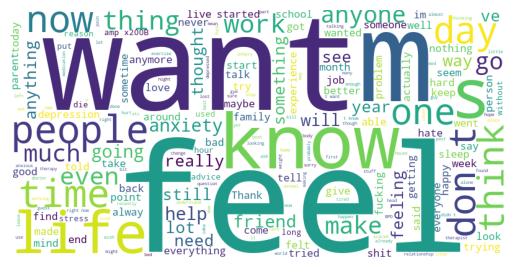

In [18]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [19]:
for label in df['label'].unique():
    subset = df[df['label'] == label]
    print(f"{label}: {len(subset)} samples")

Bipolar: 2720 samples
Suicidal: 5592 samples
Personality_disorder: 2810 samples
Anxiety: 4704 samples
Depression: 4111 samples
Stress: 1822 samples
Normal: 4574 samples


In [20]:
print(df.sample(5))

                                                    text       label  \
18094  How can I get fit? Hi. I am an 18 year old Mal...      Normal   
1134   When to increase TM in beginner prep school? H...      Normal   
14954  I need to vent. A few years ago my depression ...  Depression   
10160  i dont know if this is one of those "cry for h...    Suicidal   
16807  I don't know what I'm going through (27 years ...     Anxiety   

       text_length  
18094          244  
1134          1041  
14954         1347  
10160         1987  
16807         1158  


In [26]:
#Streaming Simulation Loop
df_stream = df.sample(frac=1).reset_index(drop=True).head(200)

In [27]:
import time

def stream_data(data, delay=0.01):
    for i, row in data.iterrows():
        text = row['text']
        label = row['label']
        
        print(f"[{i}] {text}")
        
        time.sleep(delay)

In [28]:
stream_data(df_stream, delay=0.01)

[0] DAE experience psychosis? How do you cope? I’ve dealt with psychosis for a long time, since childhood. I’m extremely nearsighted and my hearing is somewhat off. It’s usually the same things that I see or hear or feel there. Most of the time I can just power through it or get away from it but lately, I’m so tired of doing that. I’m an adult and I really feel stupid not being able to fall asleep alone in my own bed because I’ll wake up to a blurry figure there staring at me or that if I don’t have some sort of noise, I’ll hear something there. 

I was formally diagnosed as a teenager with several disorders. I took so many different medications that I can’t really remember them all. Cognitive therapy didn’t really help me either. I always give in to the fear and run away. 

I’m very afraid to see a psychiatrist again as an adult and mention the psychosis. I take anxiety medicine now but I’m afraid that I will get admitted if I even speak of it to a doctor. I’d be willing to try specif

In [29]:
def stream_generator(data):
    for _, row in data.iterrows():
        yield row['text'], row['label']

In [30]:
for text, label in stream_generator(df_stream):
    print(text)
    time.sleep(0.01)

DAE experience psychosis? How do you cope? I’ve dealt with psychosis for a long time, since childhood. I’m extremely nearsighted and my hearing is somewhat off. It’s usually the same things that I see or hear or feel there. Most of the time I can just power through it or get away from it but lately, I’m so tired of doing that. I’m an adult and I really feel stupid not being able to fall asleep alone in my own bed because I’ll wake up to a blurry figure there staring at me or that if I don’t have some sort of noise, I’ll hear something there. 

I was formally diagnosed as a teenager with several disorders. I took so many different medications that I can’t really remember them all. Cognitive therapy didn’t really help me either. I always give in to the fear and run away. 

I’m very afraid to see a psychiatrist again as an adult and mention the psychosis. I take anxiety medicine now but I’m afraid that I will get admitted if I even speak of it to a doctor. I’d be willing to try specific m

In [31]:
def stream_batches(data, batch_size=10):
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size]

In [32]:
for batch in stream_batches(df_stream, 10):
    print(batch[['text', 'label']])
    time.sleep(0.1)

                                                text       label
0  DAE experience psychosis? How do you cope? I’v...     Anxiety
1  There is no other emotion. No happiness, no lo...    Suicidal
2  Dunno if right place to post but... I've been ...     Anxiety
3  I don’t know whether I need to get my dosage i...  Depression
4  45 years old and still failing at life I've be...     Anxiety
5  Message #1 Hello. It’s me again. I say that li...  Depression
6  I don't know a lot about stress, apart from th...      Stress
7  I can't handle my own brain anymore I feel so ...  Depression
8  Spur of the moment decision biting me in the A...     Bipolar
9  I just want to leave earth. This is too much f...    Suicidal
                                                 text                 label
10  Do you not get to live if you have no money? L...            Depression
11  Does anyone feel like their physical symptoms ...               Anxiety
12  What if it's just me? These meds aren't workin...    